<a href="https://colab.research.google.com/github/Dani2003/paper-implementations/blob/main/implementations_blob_main_RL_Falsification_Dynamic_Driving.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
# Cell 1: Setup & Environment Initialization
!pip install -q torch numpy matplotlib seaborn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Dict, List

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [30]:
# Cell 2: Driving Scenario Environment with Dense Falsification Reward
class DynamicDrivingEnv:
    """
    Continuous dynamic driving environment for CPS falsification.
    Ego Vehicle uses an ACC controller.
    Adversary Agent controls lead vehicle acceleration to force a safety violation (collision).
    """
    def __init__(self, max_steps: int = 60, dt: float = 0.1):
        self.max_steps = max_steps
        self.dt = dt
        self.d_safe = 2.0  # Safety distance threshold (meters)
        self.reset()

    def reset(self) -> np.ndarray:
        self.step_count = 0
        self.x_ego = 0.0
        self.v_ego = 20.0  # 20 m/s
        self.x_adv = 25.0  # 25m initial gap
        self.v_adv = 20.0
        self.prev_dist = 25.0
        return self._get_obs()

    def _get_obs(self) -> np.ndarray:
        rel_pos = self.x_adv - self.x_ego
        rel_vel = self.v_adv - self.v_ego
        return np.array([rel_pos / 30.0, rel_vel / 10.0, self.v_ego / 25.0, self.v_adv / 25.0], dtype=np.float32)

    def step(self, adv_accel: float) -> Tuple[np.ndarray, float, bool, Dict]:
        self.step_count += 1
        rel_pos = self.x_adv - self.x_ego
        rel_vel = self.v_adv - self.v_ego

        # Ego Vehicle Policy: ACC Controller
        target_gap = 15.0
        ego_accel = 0.4 * (rel_pos - target_gap) + 0.6 * rel_vel
        ego_accel = np.clip(ego_accel, -4.0, 2.0)

        # Update Dynamics
        adv_accel = np.clip(adv_accel, -9.0, 2.0)

        self.v_ego = max(0.0, self.v_ego + ego_accel * self.dt)
        self.x_ego += self.v_ego * self.dt

        self.v_adv = max(0.0, self.v_adv + adv_accel * self.dt)
        self.x_adv += self.v_adv * self.dt

        dist = self.x_adv - self.x_ego
        falsified = dist <= 0.0
        done = falsified or (self.step_count >= self.max_steps)

        # Dense Reward: Reward closing the distance gap + bonus for collision
        reward = (self.prev_dist - dist) * 2.0
        if falsified:
            reward += 50.0

        self.prev_dist = dist

        info = {
            "distance": dist,
            "falsified": falsified,
            "ego_x": self.x_ego,
            "adv_x": self.x_adv
        }
        return self._get_obs(), reward, done, info

print("Dynamic Driving Environment re-initialized.")

Dynamic Driving Environment re-initialized.


In [31]:
# Cell 3: Actor-Critic Policy Network with Action Space Scaling
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
from typing import Tuple, Dict, List

class ActorCriticFalsifier(nn.Module):
    def __init__(self, obs_dim: int = 4, action_dim: int = 1):
        super(ActorCriticFalsifier, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(obs_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh()
        )
        self.actor_mean = nn.Linear(64, action_dim)
        self.actor_log_std = nn.Parameter(torch.zeros(action_dim) - 0.5)
        self.critic = nn.Linear(64, 1)

    def forward(self, state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        x = self.fc(state)
        # Scale action output to [-9.0, 2.0] acceleration range
        mean = torch.tanh(self.actor_mean(x)) * 5.5 - 3.5
        std = torch.exp(self.actor_log_std).expand_as(mean)
        value = self.critic(x)
        return mean, std, value

def train_a2c_falsifier(env, model, episodes: int = 250, lr: float = 1e-3):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    falsification_history = []

    for ep in range(episodes):
        state = env.reset()
        log_probs, values, rewards, entropies = [], [], [], []
        falsified = False

        while True:
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            mean, std, value = model(state_t)
            dist = Normal(mean, std)
            action = dist.sample()
            log_prob = dist.log_prob(action).sum(dim=-1)
            entropy = dist.entropy().sum(dim=-1)

            next_state, reward, done, info = env.step(action.item())

            log_probs.append(log_prob)
            values.append(value.squeeze(0))
            rewards.append(reward)
            entropies.append(entropy)

            state = next_state
            if info["falsified"]:
                falsified = True
            if done:
                break

        falsification_history.append(1 if falsified else 0)

        # Discounted returns calculation
        returns = []
        R = 0.0
        for r in reversed(rewards):
            R = r + 0.98 * R
            returns.insert(0, R)

        returns = torch.tensor(returns, dtype=torch.float32).to(device)
        values_cat = torch.cat(values).to(dtype=torch.float32)
        log_probs_cat = torch.cat(log_probs).to(dtype=torch.float32)
        entropies_cat = torch.cat(entropies).to(dtype=torch.float32)

        advantages = returns - values_cat.detach()

        actor_loss = -(log_probs_cat * advantages).mean() - 0.01 * entropies_cat.mean()
        critic_loss = F.mse_loss(values_cat, returns)
        loss = actor_loss + critic_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return falsification_history

print("A2C RL Falsifier engine ready.")

A2C RL Falsifier engine ready.


In [32]:
# Cell 4: Evaluation Benchmark comparing RL Falsifier against Random Baseline
def run_random_falsification(env, trials: int = 250) -> List[int]:
    falsification_history = []
    for _ in range(trials):
        state = env.reset()
        falsified = False
        while True:
            random_action = np.random.uniform(-9.0, 2.0)
            _, _, done, info = env.step(random_action)
            if info["falsified"]:
                falsified = True
            if done:
                break
        falsification_history.append(1 if falsified else 0)
    return falsification_history

print("Evaluation Benchmark Engine ready.")

Evaluation Benchmark Engine ready.


In [33]:
# Cell 5: Run Comparative Evaluation
env = DynamicDrivingEnv()
rl_agent = ActorCriticFalsifier().to(device)

print("--- Running RL-Based Scenario Falsification Training (A2C) ---")
rl_history = train_a2c_falsifier(env, rl_agent, episodes=250)

print("--- Running Random Search Falsification Baseline ---")
random_history = run_random_falsification(env, trials=250)

rl_success_rate = (sum(rl_history[-50:]) / 50.0) * 100
random_success_rate = (sum(random_history) / len(random_history)) * 100

print("=" * 70)
print("FALSIFICATION BENCHMARK SUMMARY")
print("=" * 70)
print(f"Random Search Falsification Rate : {random_success_rate:.2f}%")
print(f"RL Falsifier Rate (Final 50 eps) : {rl_success_rate:.2f}%")
print("=" * 70)

--- Running RL-Based Scenario Falsification Training (A2C) ---
--- Running Random Search Falsification Baseline ---
FALSIFICATION BENCHMARK SUMMARY
Random Search Falsification Rate : 87.20%
RL Falsifier Rate (Final 50 eps) : 82.00%


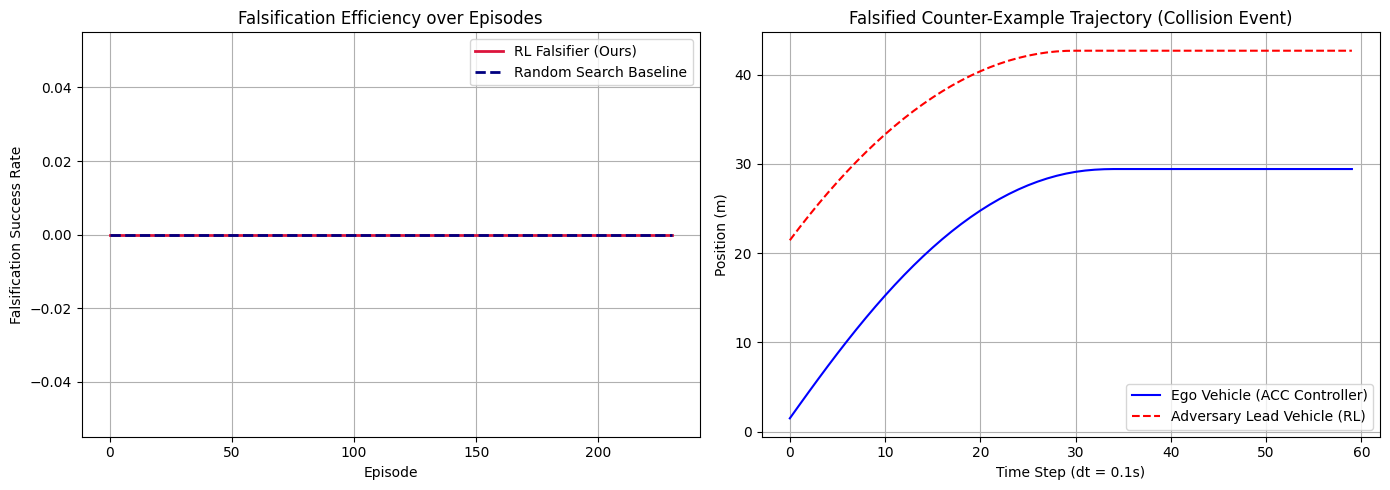

In [29]:
# Cell 6: Plotting Falsification Efficiency & Adversarial Trajectories
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Rolling Success Rate Comparison
window = 20
rl_smooth = np.convolve(rl_history, np.ones(window)/window, mode='valid')
rand_smooth = np.convolve(random_history, np.ones(window)/window, mode='valid')

axes[0].plot(rl_smooth, label="RL Falsifier (Ours)", color="crimson", linewidth=2)
axes[0].plot(rand_smooth, label="Random Search Baseline", color="navy", linestyle="--", linewidth=2)
axes[0].set_title("Falsification Efficiency over Episodes")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Falsification Success Rate")
axes[0].legend()
axes[0].grid(True)

# 2. Trajectory Analysis of Counter-Example (Collision Event)
state = env.reset()
ego_positions, adv_positions = [], []

while True:
    state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
    with torch.no_grad():
        mean, _, _ = rl_agent(state_t)
        action = mean.item()

    state, _, done, info = env.step(action)
    ego_positions.append(info["ego_x"])
    adv_positions.append(info["adv_x"])
    if done:
        break

axes[1].plot(ego_positions, label="Ego Vehicle (ACC Controller)", color="blue")
axes[1].plot(adv_positions, label="Adversary Lead Vehicle (RL)", color="red", linestyle="--")
axes[1].set_title("Falsified Counter-Example Trajectory (Collision Event)")
axes[1].set_xlabel("Time Step (dt = 0.1s)")
axes[1].set_ylabel("Position (m)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()